## 1. IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. LOAD DATA

In [2]:
df=pd.read_csv('../data/raw/flights_sample_3m.csv')

## 3. INITIAL EXPLORATION

In [3]:
pd.set_option('display.max_columns',None)
print(df.shape)
df.head()

(3000000, 32)


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1151.0,-4.0,19.0,1210.0,1443.0,4.0,1501,1447.0,-14.0,0.0,NaN,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2114.0,-6.0,9.0,2123.0,2232.0,38.0,2315,2310.0,-5.0,0.0,NaN,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1000.0,6.0,20.0,1020.0,1247.0,5.0,1252,1252.0,0.0,0.0,NaN,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1608.0,-1.0,27.0,1635.0,1844.0,9.0,1829,1853.0,24.0,0.0,NaN,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,1838.0,-2.0,15.0,1853.0,2026.0,14.0,2041,2040.0,-1.0,0.0,NaN,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

In [5]:
df.describe()

,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,3.000000e+06,3.000000e+06,3.000000e+06,2.922385e+06,2.922356e+06,2.921194e+06,2.921194e+06,2.920056e+06,2.920056e+06,3.000000e+06,2.920058e+06,2.913802e+06,3.000000e+06,3.000000e+06,2.999986e+06,2.913802e+06,2.913802e+06,3.000000e+06,533863.000000,533863.000000,533863.000000,533863.000000,533863.000000
mean,1.997629e+04,2.511536e+03,1.327062e+03,1.329776e+03,1.012333e+01,1.664305e+01,1.352361e+03,1.462500e+03,7.678982e+00,1.490561e+03,1.466511e+03,4.260858e+00,2.638000e-02,2.352000e-03,1.422758e+02,1.366205e+02,1.123108e+02,8.093616e+02,24.759086,3.985260,13.164728,0.145931,25.471282
std,3.772846e+02,1.747258e+03,4.858789e+02,4.993101e+02,4.925183e+01,9.192901e+00,5.008727e+02,5.272368e+02,6.269639e+00,5.115476e+02,5.318383e+02,5.117482e+01,1.602626e-01,4.844036e-02,7.155669e+01,7.167582e+01,6.975484e+01,5.878939e+02,71.771845,32.410796,33.161122,3.582053,55.766892
min,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-9.600000e+01,0.000000e+00,0.000000e+00,1.000000e+00,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.979000e+04,1.051000e+03,9.150000e+02,9.160000e+02,-6.000000e+00,1.100000e+01,9.310000e+02,1.049000e+03,4.000000e+00,1.107000e+03,1.053000e+03,-1.600000e+01,0.000000e+00,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.770000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.993000e+04,2.152000e+03,1.320000e+03,1.323000e+03,-2.000000e+00,1.400000e+01,1.336000e+03,1.501000e+03,6.000000e+00,1.516000e+03,1.505000e+03,-7.000000e+00,0.000000e+00,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,2.036800e+04,3.797000e+03,1.730000e+03,1.739000e+03,6.000000e+00,1.900000e+01,1.752000e+03,1.908000e+03,9.000000e+00,1.919000e+03,1.913000e+03,7.000000e+00,0.000000e+00,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000
max,2.045200e+04,9.562000e+03,2.359000e+03,2.400000e+03,2.966000e+03,1.840000e+02,2.400000e+03,2.400000e+03,2.490000e+02,2.400000e+03,2.400000e+03,2.934000e+03,1.000000e+00,1.000000e+00,7.050000e+02,7.390000e+02,6.920000e+02,5.812000e+03,2934.000000,1653.000000,1741.000000,1185.000000,2557.000000


In [6]:
df.isna().sum()

FL_DATE                          0
AIRLINE                          0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
DEST                             0
DEST_CITY                        0
CRS_DEP_TIME                     0
DEP_TIME                     77615
DEP_DELAY                    77644
TAXI_OUT                     78806
WHEELS_OFF                   78806
WHEELS_ON                    79944
TAXI_IN                      79944
CRS_ARR_TIME                     0
ARR_TIME                     79942
ARR_DELAY                    86198
CANCELLED                        0
CANCELLATION_CODE          2920860
DIVERTED                         0
CRS_ELAPSED_TIME                14
ELAPSED_TIME                 86198
AIR_TIME                     86198
DISTANCE                         0
DELAY_DUE_CARRIER          2466137
DELAY_DUE_WEATHER   

## 4. HANDLING MISSING VALUES

1. Cancelled/diverted flights have no DEP_DELAY/ARR_DELAY (they never flew) — drop them,since our problem is "will an operated flight be delayed", not "will it be cancelled"

In [7]:
print(df['CANCELLED'].value_counts())
print(df['DIVERTED'].value_counts())

CANCELLED
0.0    2920860
1.0      79140
Name: count, dtype: int64
DIVERTED
0.0    2992944
1.0       7056
Name: count, dtype: int64


In [8]:
mask=(df['CANCELLED']==0) & (df['DIVERTED']==0)
df=df[mask].copy()

In [9]:
df.isna().sum()

FL_DATE                          0
AIRLINE                          0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
DEST                             0
DEST_CITY                        0
CRS_DEP_TIME                     0
DEP_TIME                         0
DEP_DELAY                        0
TAXI_OUT                         0
WHEELS_OFF                       0
WHEELS_ON                        2
TAXI_IN                          2
CRS_ARR_TIME                     0
ARR_TIME                         2
ARR_DELAY                        2
CANCELLED                        0
CANCELLATION_CODE          2913804
DIVERTED                         0
CRS_ELAPSED_TIME                 0
ELAPSED_TIME                     2
AIR_TIME                         2
DISTANCE                         0
DELAY_DUE_CARRIER          2379941
DELAY_DUE_WEATHER   

In [34]:
df[df['ARR_DELAY'].isnull()]

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
918330,2023-05-21,Republic Airline,Republic Airline: YX,YX,20452,5612,LGA,"New York, NY",BNA,"Nashville, TN",1605,1642.0,37.0,36.0,1718.0,NaN,NaN,1746,NaN,NaN,0.0,Not Cancelled,0.0,161.0,NaN,NaN,764.0,0.0,0.0,0.0,0.0,0.0
1302862,2022-12-21,Frontier Airlines Inc.,Frontier Airlines Inc.: F9,F9,20436,777,DEN,"Denver, CO",LAS,"Las Vegas, NV",1956,1951.0,-5.0,81.0,2112.0,NaN,NaN,2100,NaN,NaN,0.0,Not Cancelled,0.0,124.0,NaN,NaN,628.0,0.0,0.0,0.0,0.0,0.0


2. Delay reason columns- the columns have NaN cause there was no delay in the flight so it's safe to replave them with 0.

In [10]:
delay_due_cols=['DELAY_DUE_CARRIER',	'DELAY_DUE_WEATHER',	'DELAY_DUE_NAS',
                'DELAY_DUE_SECURITY',	'DELAY_DUE_LATE_AIRCRAFT']

In [11]:
df[delay_due_cols]=df[delay_due_cols].fillna(0)

In [12]:
df.isna().sum()

FL_DATE                          0
AIRLINE                          0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
DEST                             0
DEST_CITY                        0
CRS_DEP_TIME                     0
DEP_TIME                         0
DEP_DELAY                        0
TAXI_OUT                         0
WHEELS_OFF                       0
WHEELS_ON                        2
TAXI_IN                          2
CRS_ARR_TIME                     0
ARR_TIME                         2
ARR_DELAY                        2
CANCELLED                        0
CANCELLATION_CODE          2913804
DIVERTED                         0
CRS_ELAPSED_TIME                 0
ELAPSED_TIME                     2
AIR_TIME                         2
DISTANCE                         0
DELAY_DUE_CARRIER                0
DELAY_DUE_WEATHER   

3. relaping NaN to 'Not Cancelled' as nan means not cancelled

In [13]:
df['CANCELLATION_CODE'].unique()

array([nan], dtype=object)

In [14]:
df["CANCELLATION_CODE"] = df["CANCELLATION_CODE"].fillna("Not Cancelled")

In [15]:
df.isna().sum()

FL_DATE                    0
AIRLINE                    0
AIRLINE_DOT                0
AIRLINE_CODE               0
DOT_CODE                   0
FL_NUMBER                  0
ORIGIN                     0
ORIGIN_CITY                0
DEST                       0
DEST_CITY                  0
CRS_DEP_TIME               0
DEP_TIME                   0
DEP_DELAY                  0
TAXI_OUT                   0
WHEELS_OFF                 0
WHEELS_ON                  2
TAXI_IN                    2
CRS_ARR_TIME               0
ARR_TIME                   2
ARR_DELAY                  2
CANCELLED                  0
CANCELLATION_CODE          0
DIVERTED                   0
CRS_ELAPSED_TIME           0
ELAPSED_TIME               2
AIR_TIME                   2
DISTANCE                   0
DELAY_DUE_CARRIER          0
DELAY_DUE_WEATHER          0
DELAY_DUE_NAS              0
DELAY_DUE_SECURITY         0
DELAY_DUE_LATE_AIRCRAFT    0
dtype: int64

## 5. LEAKAGE COLUMNS---
* These would NOT be known before/at prediction time — using them = cheating


In [16]:
df_new=df.copy()

In [17]:
df_new.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1151.0,-4.0,19.0,1210.0,1443.0,4.0,1501,1447.0,-14.0,0.0,Not Cancelled,0.0,186.0,176.0,153.0,1065.0,0.0,0.0,0.0,0.0,0.0
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2114.0,-6.0,9.0,2123.0,2232.0,38.0,2315,2310.0,-5.0,0.0,Not Cancelled,0.0,235.0,236.0,189.0,1399.0,0.0,0.0,0.0,0.0,0.0
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1000.0,6.0,20.0,1020.0,1247.0,5.0,1252,1252.0,0.0,0.0,Not Cancelled,0.0,118.0,112.0,87.0,680.0,0.0,0.0,0.0,0.0,0.0
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1608.0,-1.0,27.0,1635.0,1844.0,9.0,1829,1853.0,24.0,0.0,Not Cancelled,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,1838.0,-2.0,15.0,1853.0,2026.0,14.0,2041,2040.0,-1.0,0.0,Not Cancelled,0.0,181.0,182.0,153.0,985.0,0.0,0.0,0.0,0.0,0.0


In [18]:
leakage_cols = [
    'DEP_TIME',        
    'ARR_TIME',        
    'ARR_DELAY',       
    'TAXI_OUT', 'TAXI_IN', 'WHEELS_OFF', 'WHEELS_ON',
    'ELAPSED_TIME', 'AIR_TIME',    
    'CANCELLATION_CODE',
    'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT',
]

In [19]:
df_new['is_delayed'] = (df_new['ARR_DELAY']>15).astype(int)
df_new['delayed_in_min'] = df_new['ARR_DELAY']

df_new = df_new.drop(columns=leakage_cols + ['DEP_DELAY', 'CANCELLED', 'DIVERTED'])

In [20]:
df_new.columns.to_list()

['FL_DATE',
 'AIRLINE',
 'AIRLINE_DOT',
 'AIRLINE_CODE',
 'DOT_CODE',
 'FL_NUMBER',
 'ORIGIN',
 'ORIGIN_CITY',
 'DEST',
 'DEST_CITY',
 'CRS_DEP_TIME',
 'CRS_ARR_TIME',
 'CRS_ELAPSED_TIME',
 'DISTANCE',
 'is_delayed',
 'delayed_in_min']

## 6. EDA

In [21]:
df_new.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,is_delayed,delayed_in_min
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1501,186.0,1065.0,0,-14.0
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2315,235.0,1399.0,0,-5.0
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1252,118.0,680.0,0,0.0
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1829,260.0,1589.0,1,24.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,2041,181.0,985.0,0,-1.0


In [22]:
df_new['is_delayed'].value_counts(normalize=True)

is_delayed
0    0.823156
1    0.176844
Name: proportion, dtype: float64

**delayer- 82%**

**not_delayer- 18%**

* the taregt column data is imbalanced

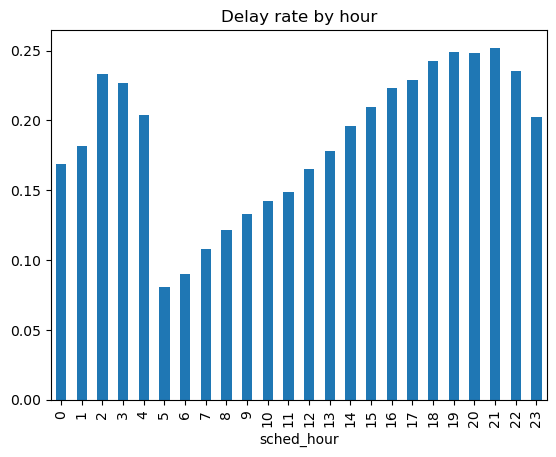

In [23]:
df_new['sched_hour'] = (df_new['CRS_DEP_TIME'] // 100).astype(int)
df_new.groupby('sched_hour')['is_delayed'].mean().plot(kind='bar', title='Delay rate by hour')
plt.show()

In [24]:
df_new['FL_DATE']=pd.to_datetime(df_new['FL_DATE'])

df_new['day_of_week']=df_new['FL_DATE'].dt.day_of_week
df_new['month']=df_new['FL_DATE'].dt.month

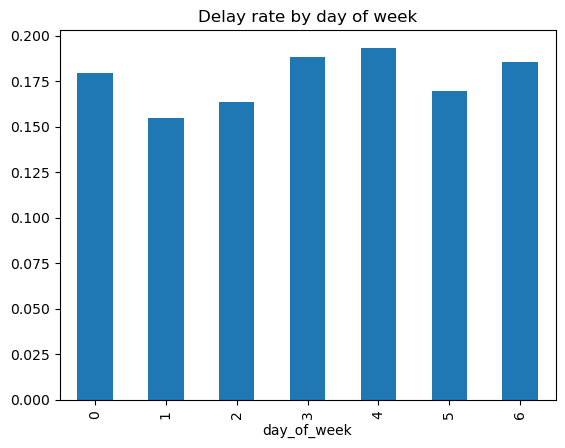

In [25]:
df_new.groupby('day_of_week')['is_delayed'].mean().plot(kind='bar', title='Delay rate by day of week')
plt.show()

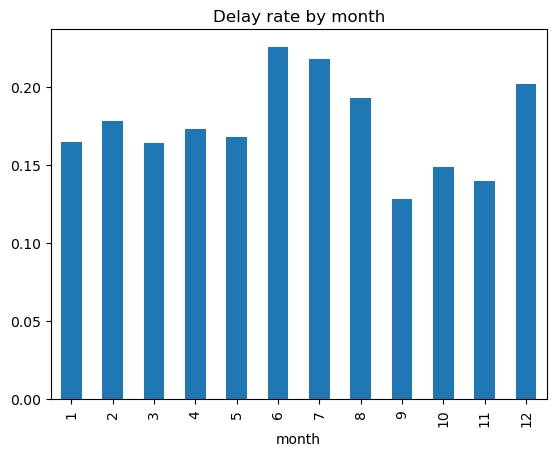

In [26]:
df_new.groupby('month')['is_delayed'].mean().plot(kind='bar', title='Delay rate by month')
plt.show()

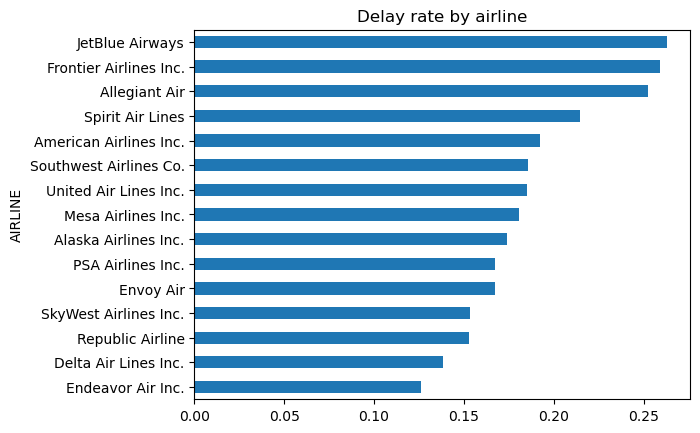

In [27]:
top_airlines = df_new['AIRLINE'].value_counts().head(15).index
subset = df_new[df_new['AIRLINE'].isin(top_airlines)]
subset.groupby('AIRLINE')['is_delayed'].mean().sort_values().plot(kind='barh', title='Delay rate by airline')
plt.show()

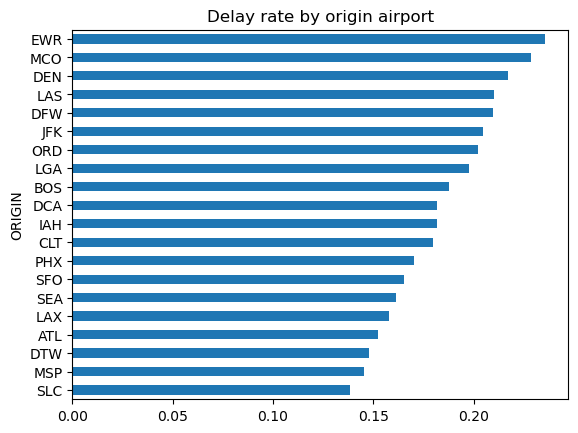

In [41]:
top_origins = df_new['ORIGIN'].value_counts().head(20).index
subset = df_new[df_new['ORIGIN'].isin(top_origins)]
subset.groupby('ORIGIN')['is_delayed'].mean().sort_values().plot(kind='barh', title='Delay rate by origin airport')
plt.show()

In [29]:
df_new['distance_bucket'] = pd.cut(df_new['DISTANCE'], bins=[0, 500, 1000, 2000, 5000],
                                labels=['short', 'medium', 'long', 'very_long'])
print(df_new.groupby('distance_bucket')['is_delayed'].mean())

distance_bucket
short        0.159953
medium       0.180641
long         0.196430
very_long    0.185182
Name: is_delayed, dtype: float64


C:\Users\Souga\AppData\Local\Temp\ipykernel_14216\752058568.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_new.groupby('distance_bucket')['is_delayed'].mean())


### Insights
1. morning(from 5am) is least prone to delay , and the delay chances gratually increase as time goes up
2. june , july, august and december has a bit more change of delay maybe because of ran in j,j,A and cold for d
3. day of week doesn't have much variation
4. a few airline(jetBlue AIrways, Frontier Airline inc, Allegient air) show a bit more delayed than other 

In [30]:
df_new.columns

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE',
       'is_delayed', 'delayed_in_min', 'sched_hour', 'day_of_week', 'month',
       'distance_bucket'],
      dtype='object')

In [43]:
a=pd.read_csv('../data/processed/flights_sample_3m_cleaned.csv')
a.head()

,FL_DATE,AIRLINE,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,is_delayed
0,2019-01-09,United Air Lines Inc.,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1501,186.0,1065.0,0
1,2022-11-19,Delta Air Lines Inc.,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2315,235.0,1399.0,0
2,2022-07-22,United Air Lines Inc.,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1252,118.0,680.0,0
3,2023-03-06,Delta Air Lines Inc.,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1829,260.0,1589.0,0
4,2020-02-23,Spirit Air Lines,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,2041,181.0,985.0,0


In [45]:
a.isnull().sum()

FL_DATE             0
AIRLINE             0
ORIGIN              0
ORIGIN_CITY         0
DEST                0
DEST_CITY           0
CRS_DEP_TIME        0
CRS_ARR_TIME        0
CRS_ELAPSED_TIME    0
DISTANCE            0
is_delayed          0
dtype: int64